# Icebreaker — QLoRA fine-tuning i evaluacija


Faze u ovom notebooku:
- **Fine-tuning** — Llama-3.2-3B-Instruct + QLoRA (Unsloth), 3 epohe
- **Inferencija** — merge adaptera, vLLM ili transformers pipeline
- **Evaluacija** — GPT-4o-mini sudija, adherence provjera, perpleksnost

Preduvjeti (vidi upute u README):
1. `dataset_train.jsonl` i `dataset_eval.jsonl` uploadani na Google Drive
2. `ANTHROPIC_API_KEY` (nije potreban ovde) i `OPENAI_API_KEY` kao Colab Secrets

## 0. Provjera GPU-a

In [1]:
import subprocess
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

import torch
print(f"CUDA dostupan : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Sun Jun 14 19:49:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Instalacija paketa


In [2]:
# Unsloth — optimizovani fine-tuning za T4/A100
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps "xformers<0.0.28" "trl>=1.0" peft accelerate bitsandbytes -q

# Evaluacija
!pip install openai vllm -q


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 98.1 MB/s eta 0:

## 2. Google Drive + API ključevi

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("OpenAI ključ učitan iz Colab Secrets.")
except Exception:
    import getpass
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

OpenAI ključ učitan iz Colab Secrets.


## 3. Konfiguracija


In [5]:
from pathlib import Path

# ── Putanje ───────────────────────────────────────────────────────────────────
DRIVE_ROOT   = Path("/content/drive/MyDrive/dappp")
DATA_DIR     = DRIVE_ROOT / "data"
TRAIN_PATH   = DATA_DIR / "dataset_train.jsonl"
EVAL_PATH    = DATA_DIR / "dataset_eval.jsonl"
ADAPTER_PATH = DRIVE_ROOT / "outputs" / "adapter"
MERGED_PATH  = DRIVE_ROOT / "outputs" / "merged_model"

ADAPTER_PATH.mkdir(parents=True, exist_ok=True)

# ── Model ─────────────────────────────────────────────────────────────────────
BASE_MODEL   = "unsloth/Llama-3.2-3B-Instruct"
MAX_SEQ_LEN  = 2048
LORA_R       = 16
LORA_ALPHA   = 16
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
EPOCHS       = 3
LOAD_IN_4BIT = True
SEED         = 42

# ── Evaluacija ────────────────────────────────────────────────────────────────
JUDGE_MODEL  = "gpt-4o-mini"

# Provjera fajlova
for p in (TRAIN_PATH, EVAL_PATH):
    status = "✓" if p.exists() else "✗  NEDOSTAJE"
    print(f"{status}  {p}")

✓  /content/drive/MyDrive/dappp/data/dataset_train.jsonl
✓  /content/drive/MyDrive/dappp/data/dataset_eval.jsonl


## 4. Učitavanje podataka

In [6]:
import json

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl(TRAIN_PATH)
eval_data  = load_jsonl(EVAL_PATH)

print(f"Train primjeri : {len(train_data)}")
print(f"Eval primjeri  : {len(eval_data)}")
print()
print("Primjer train zapisa:")
ex = train_data[0]
print(f"  persona_id : {ex['persona_id']}")
print(f"  temperature: {ex['temperature']}")
print(f"  user       : {ex['messages'][0]['content']}")
print(f"  assistant  : {ex['messages'][1]['content']}")

Train primjeri : 1272
Eval primjeri  : 225

Primjer train zapisa:
  persona_id : 408
  temperature: 0.5
  user       : Bio: I've got a few iguanas keeping me company and a brother I'm still getting to know. Fair warning: I'm convinced dogs could totally learn to read with the right training, and I'm definitely the type to give my pets sassy names that somehow make everyone smile.
Write an icebreaker.
  assistant  : If you had to give a dog a name that sounds sassy but makes people think happy thoughts, what would it be?


## 5. Učitavanje modela (Unsloth + 4-bit)

In [7]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = BASE_MODEL,
    max_seq_length= MAX_SEQ_LEN,
    dtype         = None,        # auto: float16 na T4, bfloat16 na Ampere+
    load_in_4bit  = LOAD_IN_4BIT,
)

print(f"Model učitan: {BASE_MODEL}")
print(f"Dtype: {model.dtype}")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.



  uv pip install https://github.com/vllm-project/vllm/releases/download/v0.23.0/vllm-0.23.0+cu128-cp38-abi3-manylinux_2_35_x86_64.whl


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.7: Fast Llama patching. Transformers: 5.12.0. vLLM: 0.23.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


Model učitan: unsloth/Llama-3.2-3B-Instruct
Dtype: torch.float16


## 6. LoRA adapter

In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = LORA_TARGETS,
    lora_dropout   = 0,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = SEED,
)

# Broj trenirajućih parametara
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trenirajući parametri: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.6.7 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


Trenirajući parametri: 9,175,040 / 1,850,387,456 (0.50%)


## 7. Formatiranje dataseta (chat template)

In [9]:
from datasets import Dataset

def format_example(example):
    """Primjenjuje tokenizerov chat template na messages listu."""
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize          = False,
        add_generation_prompt = False,
    )
    return {"text": text}

train_ds = Dataset.from_list(train_data).map(format_example)

print(f"Train dataset: {len(train_ds)} primjera")
print("\nPrimjer formatirano:")
print(train_ds[0]["text"][:400], "...")

Map:   0%|          | 0/1272 [00:00<?, ? examples/s]

Train dataset: 1272 primjera

Primjer formatirano:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 14 Jun 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

Bio: I've got a few iguanas keeping me company and a brother I'm still getting to know. Fair warning: I'm convinced dogs could totally learn to read with the right training, and I'm definitely the type to give my pets sassy  ...


## 8. Trening (SFTTrainer)

> Na T4: ~15–25 minuta za 3 epohe, 1272 primjera.

In [10]:
from trl import SFTTrainer
for c in SFTTrainer.__mro__:
    print(c.__module__, c.__name__)

UnslothSFTTrainer UnslothSFTTrainer
UnslothSFTTrainer _UnslothSFTTrainer
trl.trainer.base_trainer _BaseTrainer
transformers.trainer Trainer
builtins object


In [11]:
import trl, transformers, unsloth
print("trl:", trl.__version__, "| transformers:", transformers.__version__, "| unsloth:", unsloth.__version__)

trl: 1.6.0 | transformers: 5.12.0 | unsloth: 2026.6.7


In [14]:
import inspect
from trl import SFTTrainer
from unsloth import is_bfloat16_supported

_training_kwargs = dict(
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    warmup_steps                = 5,
    num_train_epochs            = EPOCHS,
    learning_rate               = 2e-4,
    fp16                        = not is_bfloat16_supported(),
    bf16                        = is_bfloat16_supported(),
    logging_steps               = 10,
    optim                       = "adamw_8bit",
    weight_decay                = 0.01,
    lr_scheduler_type           = "linear",
    seed                        = SEED,
    output_dir                  = "/content/train_logs",
    report_to                   = "none",
)

# SFT-specifični parametri (u novijim verzijama idu u SFTConfig)
_sft_kwargs = dict(
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LEN,
    dataset_num_proc   = 2,
    packing            = False,
    # bez packinga, padding_free mora biti False da bi max_length bio ispoštovan
    padding_free       = False,
)

# 1) tokenizer vs processing_class — zavisno od verzije
sft_sig = inspect.signature(SFTTrainer.__init__).parameters
tok_key = "processing_class" if "processing_class" in sft_sig else "tokenizer"

# 2) SFTConfig ako postoji, inače TrainingArguments
try:
    from trl import SFTConfig as _CfgCls
except ImportError:
    from transformers import TrainingArguments as _CfgCls
cfg_sig = inspect.signature(_CfgCls.__init__).parameters
cfg_takes_kwargs = any(p.kind == p.VAR_KEYWORD for p in cfg_sig.values())

# poseban slučaj: max_seq_length je u novijim verzijama preimenovan u max_length
if ("max_seq_length" not in cfg_sig and (cfg_takes_kwargs or "max_length" in cfg_sig)):
    _sft_kwargs["max_length"] = _sft_kwargs.pop("max_seq_length")

# rasporedi SFT params: u config ako ih prima, inače u konstruktor trainera,
# a ako ih ne prima nijedno (npr. padding_free u staroj verziji) — preskoči
cfg_extra, trainer_extra = {}, {}
for k, v in _sft_kwargs.items():
    if cfg_takes_kwargs or k in cfg_sig:
        cfg_extra[k] = v
    elif k in sft_sig:
        trainer_extra[k] = v

args = _CfgCls(**_training_kwargs, **cfg_extra)

trainer = SFTTrainer(
    model         = model,
    train_dataset = train_ds,
    args          = args,
    **{tok_key: tokenizer},
    **trainer_extra,
)

train_result = trainer.train()
print(f"\nTrening završen. Runtime: {train_result.metrics['train_runtime']:.0f}s")

/content/unsloth_compiled_cache/UnslothSFTTrainer.py:646: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  super().__init__(


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/1272 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,272 | Num Epochs = 3 | Total steps = 477
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 9,175,040 of 3,221,924,864 (0.28% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
10,4.006744
20,2.404954
30,1.830347
40,1.715599
50,1.658238
60,1.584296
70,1.590295
80,1.618162
90,1.581552
100,1.536803


Unsloth: Restored added_tokens_decoder metadata in /content/train_logs/checkpoint-477/tokenizer_config.json.



Trening završen. Runtime: 882s


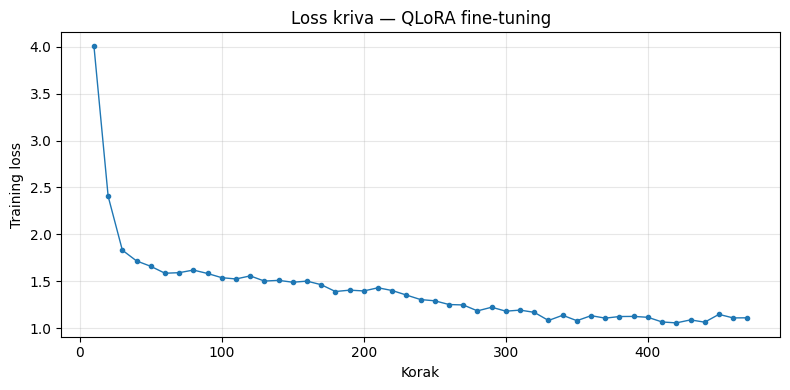

Finalni loss: 1.1088


In [15]:
# Loss kriva
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps  = [x["step"] for x in log_history if "loss" in x]
losses = [x["loss"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker=".", linewidth=1)
plt.xlabel("Korak")
plt.ylabel("Training loss")
plt.title("Loss kriva — QLoRA fine-tuning")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/loss_curve.png", dpi=120)
plt.show()
print(f"Finalni loss: {losses[-1]:.4f}")

## 9. Čuvanje adaptera

In [16]:
model.save_pretrained(str(ADAPTER_PATH))
tokenizer.save_pretrained(str(ADAPTER_PATH))
print(f"Adapter sačuvan: {ADAPTER_PATH}")

# Provjera da se adapter može ponovo učitati
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# Brzi sanity check: učitaj adapter i generiši 1 primjer
FastLanguageModel.for_inference(model)
sample = eval_data[0]
bio_text = sample["messages"][0]["content"]

inputs = tokenizer.apply_chat_template(
    [{"role": "user", "content": bio_text}],
    tokenize=True, add_generation_prompt=True, return_tensors="pt"
).to("cuda")

outputs = model.generate(inputs, max_new_tokens=60, temperature=0.7, do_sample=True)
generated = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

print(f"\nSanity check:")
print(f"  Input  : {bio_text}")
print(f"  Output : {generated}")

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/dappp/outputs/adapter/tokenizer_config.json.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=60) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages

Adapter sačuvan: /content/drive/MyDrive/dappp/outputs/adapter


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppr


Sanity check:
  Input  : Bio: Early riser who loves a good workout before the day starts. You'll find me in costumes whenever possible, cold drink in hand, stargazing with my pet by my side.
Write an icebreaker.
  Output : So if I put you in a costume and we went stargazing together, would you be more of a 'let's stay up late and talk about the universe' person or a 'let's get some rest and enjoy the view' person?


---
## 10. Merge adaptera u bazni model

> Merge je potreban za vLLM. Traje ~2 minuta, rezultat je ~6 GB na Driveu.

In [17]:
MERGED_PATH.mkdir(parents=True, exist_ok=True)

model.save_pretrained_merged(
    str(MERGED_PATH),
    tokenizer,
    save_method = "merged_16bit",   # float16, ~6 GB
)
print(f"Merged model sačuvan: {MERGED_PATH}")

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/dappp/outputs/merged_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]


Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [02:22<00:00, 71.29s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)



Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [04:32<00:00, 136.17s/it]


Unsloth: Merge process complete. Saved to `/content/drive/MyDrive/dappp/outputs/merged_model`
Merged model sačuvan: /content/drive/MyDrive/dappp/outputs/merged_model


## 11. Inferencija


In [18]:
import gc
import torch

def generate_icebreaker_unsloth(bio: str) -> str:
    """Generacija icebreakera koristeći već učitani Unsloth model."""
    inputs = tokenizer.apply_chat_template(
        [{"role": "user", "content": f"Bio: {bio}\nWrite an icebreaker."}],
        tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to("cuda")
    with torch.no_grad():
        out = model.generate(
            inputs, max_new_tokens=80,
            temperature=0.7, do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True).strip()


def try_load_vllm():
    """Vraća vLLM engine ili None ako nije dostupan."""
    try:
        from vllm import LLM, SamplingParams
        if not MERGED_PATH.exists():
            print("[warn] Merged model ne postoji, koristim Unsloth.")
            return None, None
        # Oslobodi memoriju od trening modela
        global model
        del model; gc.collect(); torch.cuda.empty_cache()
        llm    = LLM(model=str(MERGED_PATH), dtype="float16", gpu_memory_utilization=0.88)
        params = SamplingParams(temperature=0.7, max_tokens=80)
        print("[info] vLLM engine učitan.")
        return llm, params
    except Exception as e:
        print(f"[warn] vLLM nije dostupan ({e}), koristim Unsloth.")
        return None, None


vllm_engine, vllm_params = try_load_vllm()
USE_VLLM = vllm_engine is not None
print(f"Inferencija: {'vLLM' if USE_VLLM else 'Unsloth pipeline'}")

[warn] vLLM nije dostupan (No module named 'vllm'), koristim Unsloth.
Inferencija: Unsloth pipeline


In [19]:
def generate_icebreaker(bio: str) -> str:
    if USE_VLLM:
        prompt = tokenizer.apply_chat_template(
            [{"role": "user", "content": f"Bio: {bio}\nWrite an icebreaker."}],
            tokenize=False, add_generation_prompt=True
        )
        return vllm_engine.generate([prompt], vllm_params)[0].outputs[0].text.strip()
    return generate_icebreaker_unsloth(bio)


def parse_bio(content: str) -> str:
    text = content[5:] if content.startswith("Bio: ") else content
    return text.split("\n")[0].strip()


# Generiši za prvih 5 eval primjera
print("Primjeri generacije na eval skupu:")
print("=" * 70)
for item in eval_data[:5]:
    bio  = parse_bio(item["messages"][0]["content"])
    gold = item["messages"][1]["content"]
    gen  = generate_icebreaker(bio)
    print(f"BIO  : {bio}")
    print(f"GOLD : {gold}")
    print(f"GEN  : {gen}")
    print("-" * 70)

Primjeri generacije na eval skupu:


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BIO  : Early riser who loves a good workout before the day starts. You'll find me in costumes whenever possible, cold drink in hand, stargazing with my pet by my side.
GOLD : I have to know: do you think Halloween should be a year-round holiday, or is that just me?
GEN  : Do you think my pet would make a good workout buddy, or should I just stick with my cold drink?
----------------------------------------------------------------------


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BIO  : Early riser who loves a good workout before the day starts. You'll find me in costumes whenever possible, sipping cold drinks while hanging out with my pet and gazing at the sky.
GOLD : Quick question: are you a cold drink or a costume person, or do I need to find someone who appreciates both? 👀
GEN  : Do you think aliens would be more impressed by someone who can eat a cold drink from a can or someone who can do a perfect deadlift before sunrise?
----------------------------------------------------------------------


...

BIO  : Early riser who loves a good workout before the day starts. You'll find me in costume whenever possible, cold drink in hand, with my pet by my side and my eyes on the sky.
GOLD : On a scale of 1-10, how committed are you to matching my Halloween dedication? 🎃
GEN  : Do you have a favorite skywatching spot, or should I be worried I'm going to show up at your house at 6am to go for a run and steal your thunder?
----------------------------------------------------------------------


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BIO  : I'm drawn to darker aesthetics and love getting outside for long walks—especially since I'm lucky enough to live near some great outdoor spots. No kids, just me and the trails.
GOLD : Do you have a go-to walking trail nearby, or are you more of a 'discover a new path every time' person?
GEN  : Do you prefer the type of people who show up on time for walks, or the type who makes us all late? 😄
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


BIO  : I'm drawn to darker aesthetics and love getting outside for walks, especially since I live near some great trails. No kids here—just someone who values a low-key life close to nature.
GOLD : Do you have a go-to walking spot nearby, or are you more of an 'wherever the mood takes me' type of person?
GEN  : Do you prefer trails with a lot of foot traffic or are you more of a solo wanderer? 🌳
----------------------------------------------------------------------


---
## 12. Evaluacija — LLM-as-a-Judge (GPT-4o-mini)

GPT ocjenjuje naturalnost, specifičnost i ton na skali 1–5.
Sudija je iz **druge familije** od generatora (Claude), čime je self-preference bias eliminisan.

In [20]:
import re
import openai

client = openai.OpenAI()

_JUDGE_PROMPT = """You are evaluating a dating app icebreaker message.

Bio: {bio}
Icebreaker: {icebreaker}

Rate on 1–5:
- naturalness: how natural and flirtatious the tone is (1=awkward, 5=very natural)
- specificity: how specific to the bio (1=generic, 5=highly specific)
- tone: consistency of playful tone (1=inconsistent, 5=perfectly consistent)
- overall: overall quality (1=poor, 5=excellent)

Return JSON only, no prose: {{"naturalness": N, "specificity": N, "tone": N, "overall": N, "comment": "one sentence"}}"""


def judge(bio: str, icebreaker: str) -> dict | None:
    try:
        resp = client.chat.completions.create(
            model       = JUDGE_MODEL,
            messages    = [{"role": "user", "content": _JUDGE_PROMPT.format(bio=bio, icebreaker=icebreaker)}],
            temperature = 0,
            max_tokens  = 120,
        )
        text = resp.choices[0].message.content.strip()
        # Izvuci JSON čak i ako model doda prozu
        m = re.search(r'\{.*\}', text, re.DOTALL)
        return json.loads(m.group()) if m else None
    except Exception as e:
        print(f"  [warn] Judge API error: {e}")
        return None


print("Pokrećem GPT-sudiju na svim eval primjerima...")
import random
random.seed(42)

# Generiši i ocijeni sve eval primjere
eval_results = []
for i, item in enumerate(eval_data):
    bio  = parse_bio(item["messages"][0]["content"])
    gold = item["messages"][1]["content"]
    gen  = generate_icebreaker(bio)
    scores = judge(bio, gen)
    eval_results.append({"bio": bio, "gold": gold, "generated": gen, "scores": scores})
    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(eval_data)}] ocijenjeno...")

print(f"Evaluacija završena. {sum(1 for r in eval_results if r['scores'])} uspješnih ocjena.")

Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Pokrećem GPT-sudiju na svim eval primjerima...


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [25/225] ocijenjeno...


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

...

  [175/225] ocijenjeno...


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [200/225] ocijenjeno...


Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=80) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

  [225/225] ocijenjeno...
Evaluacija završena. 225 uspješnih ocjena.


## 13. Evaluacija — Adherence (vjernost personi)

In [21]:
_ADHERENCE_PROMPT = """Check if the icebreaker introduces any facts NOT mentioned in the bio.

Bio: {bio}
Icebreaker: {icebreaker}

Return JSON only: {{"hallucination": true/false, "unsupported_claims": ["claim1", ...]}}
hallucination=true means the icebreaker adds facts not in the bio."""


def check_adherence(bio: str, icebreaker: str) -> dict | None:
    try:
        resp = client.chat.completions.create(
            model       = JUDGE_MODEL,
            messages    = [{"role": "user", "content": _ADHERENCE_PROMPT.format(bio=bio, icebreaker=icebreaker)}],
            temperature = 0,
            max_tokens  = 100,
        )
        text = resp.choices[0].message.content.strip()
        m = re.search(r'\{.*\}', text, re.DOTALL)
        return json.loads(m.group()) if m else None
    except Exception as e:
        print(f"  [warn] Adherence API error: {e}")
        return None


print("Pokrećem adherence provjeru...")
for i, result in enumerate(eval_results):
    result["adherence"] = check_adherence(result["bio"], result["generated"])
    if (i + 1) % 25 == 0:
        print(f"  [{i+1}/{len(eval_results)}] provjereno...")

n_ok = sum(1 for r in eval_results
           if r["adherence"] and not r["adherence"].get("hallucination", True))
print(f"Bez halucinacija: {n_ok}/{len(eval_results)} ({100*n_ok/len(eval_results):.1f}%)")

Pokrećem adherence provjeru...
  [25/225] provjereno...
  [50/225] provjereno...
  [75/225] provjereno...
  [100/225] provjereno...
  [125/225] provjereno...
  [150/225] provjereno...
  [175/225] provjereno...
  [200/225] provjereno...
  [225/225] provjereno...
Bez halucinacija: 1/225 (0.4%)


## 14. Evaluacija — Perpleksnost

In [22]:
import torch
import numpy as np

# Osiguraj da je model u inference modu
if not USE_VLLM:
    FastLanguageModel.for_inference(model)

def compute_perplexity_on_eval(eval_data, n_samples=50):
    """Procjena perpleksnosti na eval skupu.
    Koristi prvih n_samples primjera radi brzine.
    """
    if USE_VLLM:
        print("[warn] Perpleksnost nije dostupna sa vLLM. Preskoči ili učitaj model ponovo.")
        return None

    losses = []
    model.eval()

    for item in eval_data[:n_samples]:
        text = tokenizer.apply_chat_template(
            item["messages"],
            tokenize=False, add_generation_prompt=False
        )
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LEN)
        enc = {k: v.to("cuda") for k, v in enc.items()}

        with torch.no_grad():
            out = model(**enc, labels=enc["input_ids"])
        losses.append(out.loss.item())

    ppl = float(np.exp(np.mean(losses)))
    return ppl


print("Računam perpleksnost na 50 eval primjera...")
ppl = compute_perplexity_on_eval(eval_data, n_samples=50)
if ppl:
    print(f"Perpleksnost (eval, n=50): {ppl:.2f}")
    print("Napomena: nizak loss ≠ kvalitet; perpleksnost mjeri prihvaćenu strukturu formata.")

Računam perpleksnost na 50 eval primjera...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Perpleksnost (eval, n=50): 3.55
Napomena: nizak loss ≠ kvalitet; perpleksnost mjeri prihvaćenu strukturu formata.


## 15. Završni izvještaj

In [23]:
import statistics

scored = [r for r in eval_results if r["scores"]]
adh    = [r for r in eval_results if r["adherence"]]

def avg(key):
    vals = [r["scores"][key] for r in scored if key in r["scores"]]
    return statistics.mean(vals) if vals else 0.0

n_no_hall = sum(1 for r in adh if not r["adherence"].get("hallucination", True))
adherence_pct = 100 * n_no_hall / len(adh) if adh else 0

print("=" * 50)
print(" EVALUACIJA — Icebreaker Fine-tuned Model")
print("=" * 50)
print(f" Model          : {BASE_MODEL} + QLoRA (r={LORA_R})")
print(f" Eval primjera  : {len(eval_data)}")
print(f" Ocijenjenih    : {len(scored)} / {len(eval_data)}")
print()
print(" GPT-judge (1–5):")
print(f"   Naturalnost  : {avg('naturalness'):.2f}")
print(f"   Specifičnost : {avg('specificity'):.2f}")
print(f"   Ton          : {avg('tone'):.2f}")
print(f"   Ukupno       : {avg('overall'):.2f}")
print()
print(f" Adherence      : {adherence_pct:.1f}% bez halucinacija")
print(f" Perpleksnost   : {ppl:.2f}" if ppl else " Perpleksnost   : N/A")
print("=" * 50)

# Najslabiji primjeri (lowest overall score)
weakest = sorted(scored, key=lambda r: r["scores"].get("overall", 5))[:3]
print("\nNajslabiji primjeri (overall ocjena):")
for r in weakest:
    sc = r["scores"]
    print(f"  [{sc.get('overall', '?')}/5] Bio: {r['bio'][:60]}...")
    print(f"         Gen: {r['generated'][:80]}...")
    print(f"         Komentar: {sc.get('comment', '')}")

 EVALUACIJA — Icebreaker Fine-tuned Model
 Model          : unsloth/Llama-3.2-3B-Instruct + QLoRA (r=16)
 Eval primjera  : 225
 Ocijenjenih    : 225 / 225

 GPT-judge (1–5):
   Naturalnost  : 4.07
   Specifičnost : 4.65
   Ton          : 4.91
   Ukupno       : 4.40

 Adherence      : 0.4% bez halucinacija
 Perpleksnost   : 3.55

Najslabiji primjeri (overall ocjena):
  [3/5] Bio: Violinist who's competed a fair bit and actually placed in s...
         Gen: So if you had to choose between me playing violin at a wedding or my sister play...
         Komentar: The message is playful and specific but may come off as a bit morbid.
  [4/5] Bio: Early riser who loves a good workout before the day starts. ...
         Gen: So if I showed up to a date in a full superhero costume, would you judge me for ...
         Komentar: The message is playful and aligns well with the bio, making it a fun icebreaker.
  [4/5] Bio: I'm drawn to darker aesthetics and love getting outside for ...
         Gen: S